# Telco Customer Churn Analysis

## Project Overview

Customer churn is one of the biggest challenges for telecommunication companies, as losing customers directly impacts revenue and business growth.
This project analyzes customer behavior using Python to clean the dataset and perform exploratory data analysis (EDA). The objective is to identify the key factors associated with customer churn and generate meaningful business insights.

## Project Objectives

- Understand the dataset.
- Clean and prepare the data for analysis.
- Perform exploratory data analysis (EDA).
- Identify the key factors associated with customer churn.
- Generate meaningful business insights.

## Dataset Information

The dataset contains customer demographic information, subscribed services, account details, billing information, payment methods, and customer churn status. It is used to analyze customer behavior and identify factors associated with customer churn.

#### Importing Required Libraries
The following libraries are imported for data manipulation, visualization, and analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning
In this section, the dataset is inspected and cleaned by checking missing values, correcting data types, and validating data quality before performing analysis.

In [3]:
df.shape

(7043, 21)

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].isnull().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.to_csv('telco_cleaned.csv',index=False)

## Data Cleaning Summary

The dataset has been cleaned by correcting data types, handling missing values, and validating data quality. It is now ready for exploratory data analysis.

---

## Exploratory Data Analysis (EDA)

**Exploratory Data Analysis (EDA)** was performed to understand customer behavior and identify the factors associated with customer churn. Different visualizations were used to analyze demographic characteristics, service usage, billing patterns, and customer account information. The insights obtained from this analysis help explain the possible reasons behind customer churn.

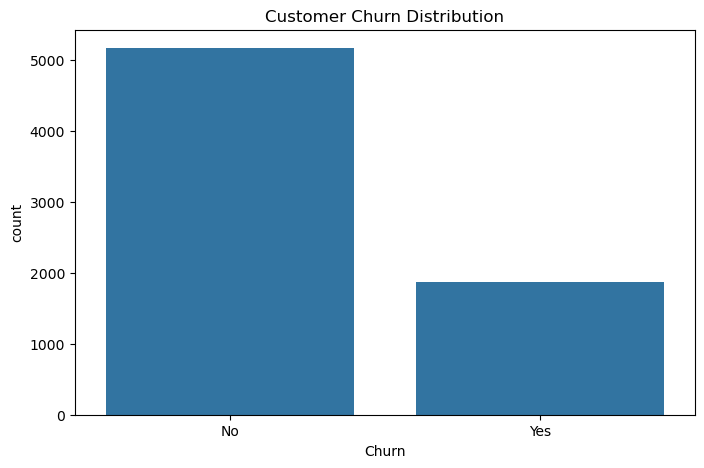

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data = df,x='Churn')
plt.title('Customer Churn Distribution')
plt.show()

In [11]:
(df['Churn'].value_counts(normalize=True)*100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Most customers stayed with the company, while a smaller portion churned. However, the number of customers who left is still significant, indicating the need to identify the factors contributing to customer churn.

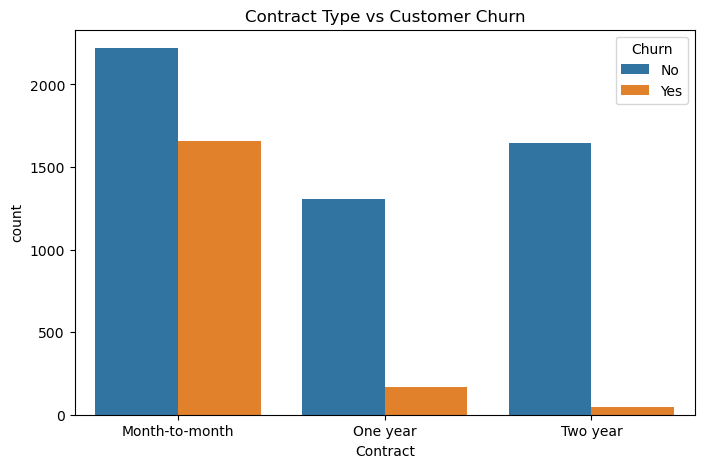

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract' , hue='Churn')
plt.title('Contract Type vs Customer Churn')
plt.show()

Customers with month-to-month contracts have the highest churn rate. In contrast, customers with one-year and two-year contracts are much less likely to leave the company. This suggests that longer contract commitments improve customer retention and reduce churn.

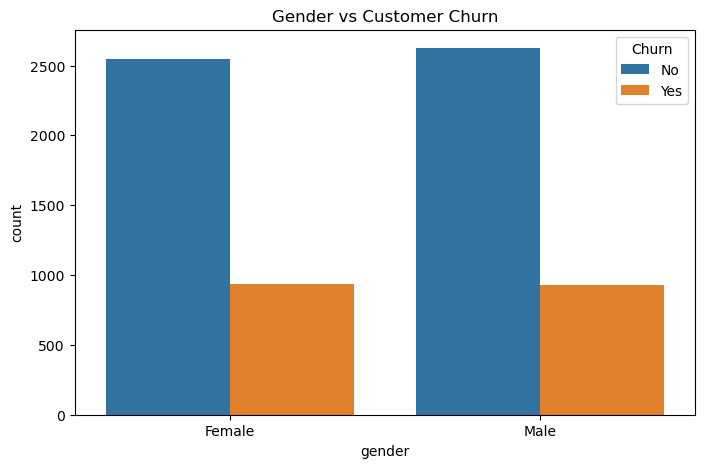

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='gender', hue='Churn')
plt.title('Gender vs Customer Churn')
plt.show()

Churn rate is nearly the same for both male and female customers. This indicates that gender does not have a significant impact on customer churn.

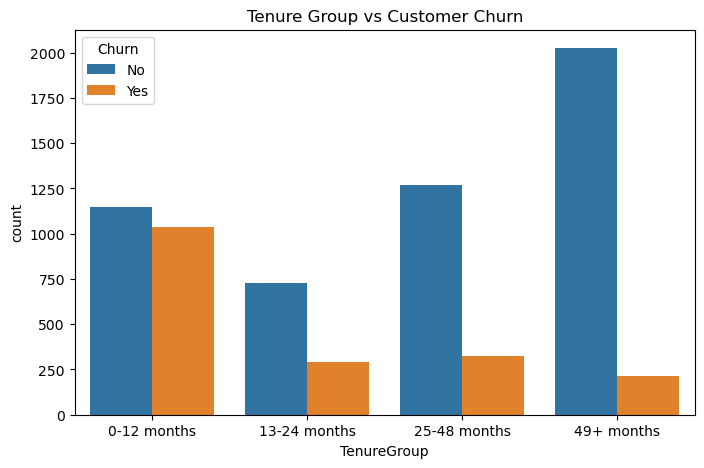

In [14]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 months'
    elif tenure <= 24:
        return '13-24 months'
    elif tenure <= 48:
        return '25-48 months'
    else:
        return '49+ months'

df['TenureGroup'] = df['tenure'].apply(tenure_group)
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='TenureGroup', hue='Churn', order=['0-12 months','13-24 months','25-48 months','49+ months'])
plt.title('Tenure Group vs Customer Churn')
plt.show()

Customers in the 0-12 months tenure group have the highest churn rate, while churn decreases steadily as tenure increases. This confirms that new customers are the most at risk of leaving, and retention efforts should focus heavily on the first year.

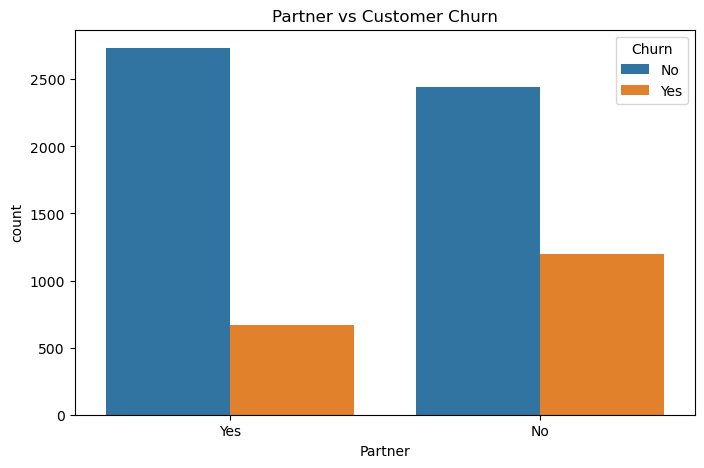

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Partner', hue='Churn')
plt.title('Partner vs Customer Churn')
plt.show()

Customers without a partner show a higher churn rate, possibly due to lower switching costs or less commitment to a single provider. This customer segment could be prioritized for targeted retention offers.

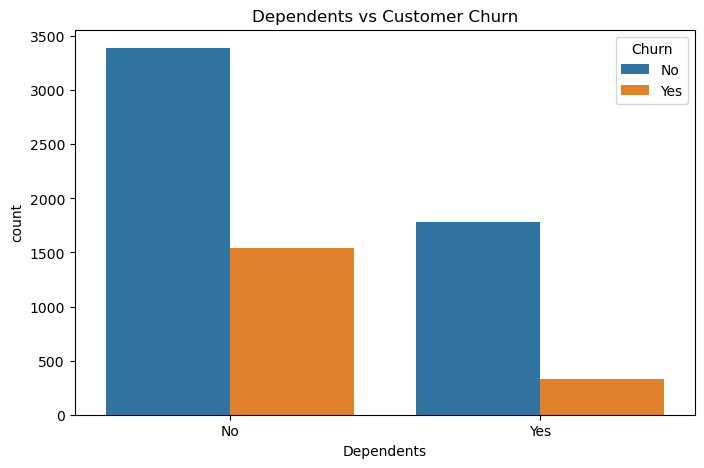

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Dependents', hue='Churn')
plt.title('Dependents vs Customer Churn')
plt.show()

Customers without dependents churn more than those with dependents, following a similar pattern to the Partner variable — customers with family responsibilities tend to stay longer with a stable provider.

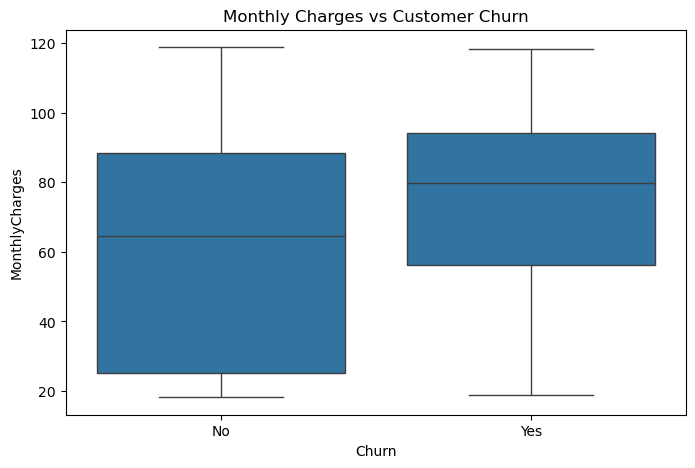

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df , x='Churn' , y='MonthlyCharges')
plt.title('Monthly Charges vs Customer Churn')
plt.show()

Customers with higher monthly charges are more likely to churn than those with lower monthly charges. This suggests that higher service costs may contribute to customers leaving the company.

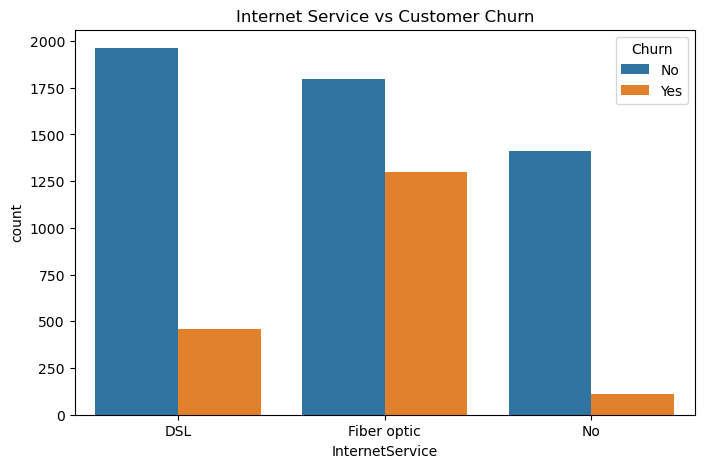

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df , x='InternetService' , hue='Churn')
plt.title('Internet Service vs Customer Churn')
plt.show()

Customers using Fiber optic internet service have the highest churn compared to DSL and customers with no internet service. In contrast, customers without internet service show the lowest churn, indicating that internet service type may influence customer retention.

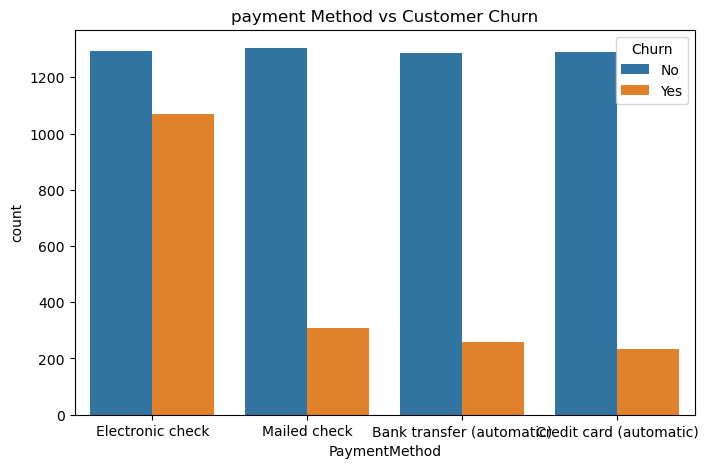

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df , x='PaymentMethod' , hue='Churn')
plt.title('payment Method vs Customer Churn')
plt.show()

Customers using electronic check have the highest churn compared to all other payment methods. In contrast, customers using automatic payment methods (bank transfer and credit card) show much lower churn, suggesting that automatic payments are associated with better customer retention.

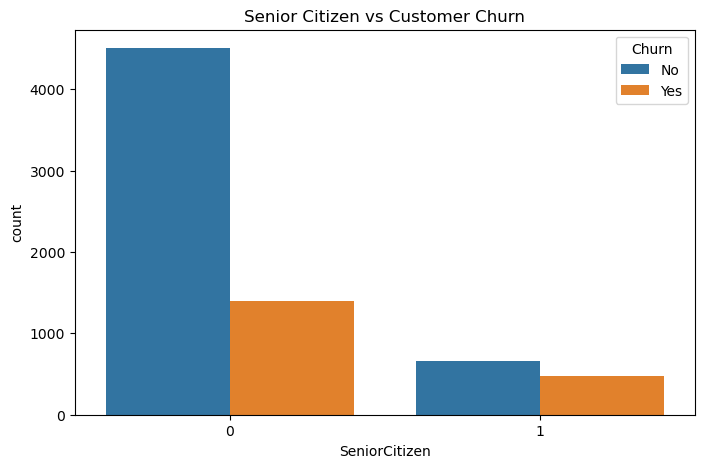

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=df , x='SeniorCitizen' , hue='Churn')
plt.title('Senior Citizen vs Customer Churn')
plt.show()

Senior citizens have a higher churn tendency than non-senior customers. The company should provide special plans, discounts, or dedicated support for senior citizens to improve customer retention.

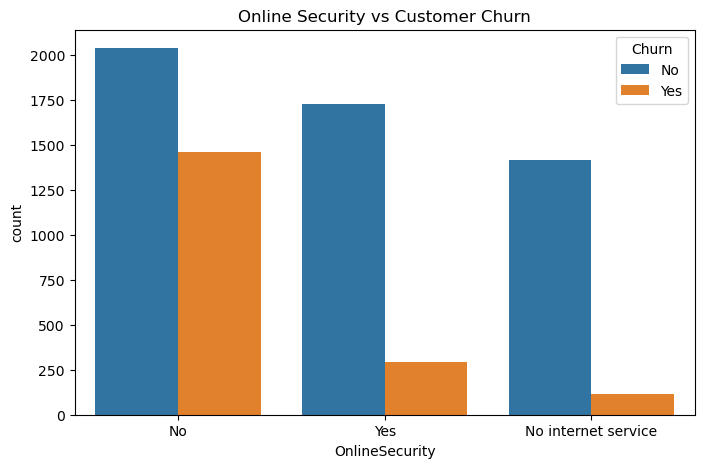

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(data=df , x='OnlineSecurity' , hue='Churn')
plt.title('Online Security vs Customer Churn')
plt.show()

Customers without online security show a significantly higher churn rate. Customers who subscribe to online security are more likely to stay with the company, indicating that security-related services can improve customer retention.

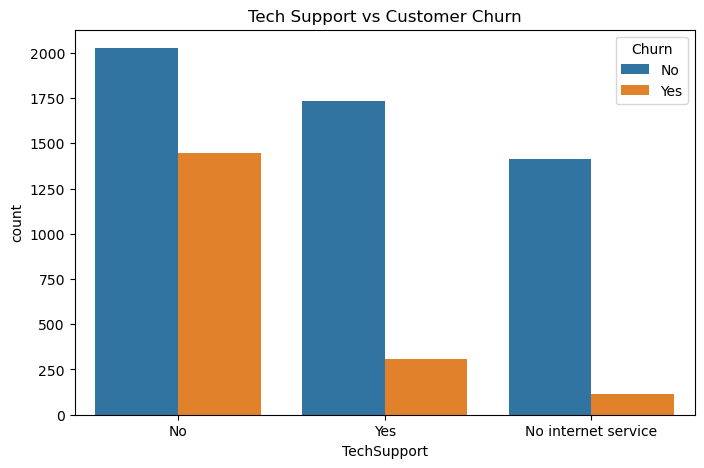

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('Tech Support vs Customer Churn')
plt.show()

Customers without technical support have a significantly higher churn rate. Providing reliable technical support can improve customer satisfaction, increase customer retention, and reduce churn.

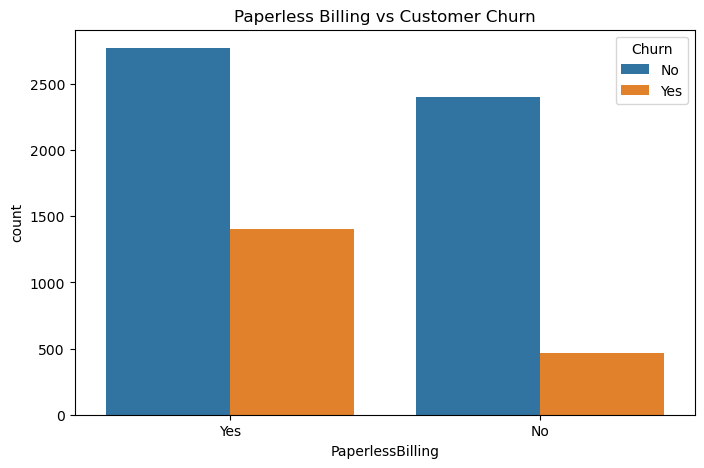

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='PaperlessBilling', hue='Churn')
plt.title('Paperless Billing vs Customer Churn')
plt.show()

Customers using paperless billing show a higher churn rate than customers using paper billing. However, this relationship indicates an association rather than a direct cause, and other factors such as contract type or monthly charges may also influence churn.

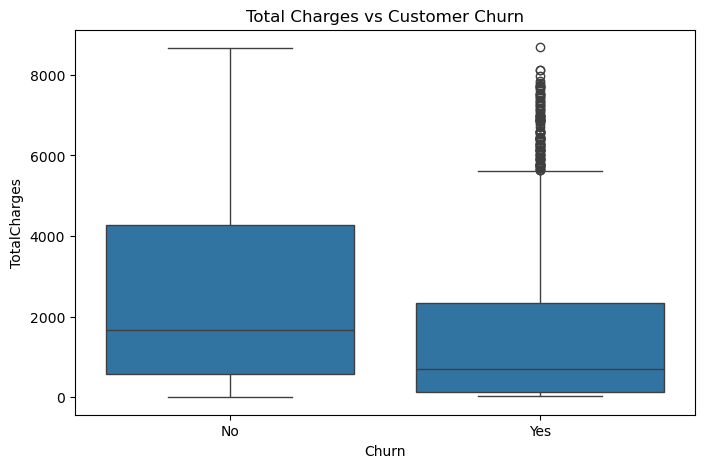

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('Total Charges vs Customer Churn')
plt.show()

Non-churned customers have higher TotalCharges overall, while churned customers show lower TotalCharges with a compressed distribution. This is directly linked to tenure — since churned customers leave earlier, they naturally accumulate fewer total charges.

In [25]:
print("Churn rate by Contract:")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).round(2)*100)

print("\nChurn rate by InternetService:")
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True).round(2)*100)

print("\nChurn rate by PaymentMethod:")
print(df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).round(2)*100)

Churn rate by Contract:
Contract        Churn
Month-to-month  No       57.0
                Yes      43.0
One year        No       89.0
                Yes      11.0
Two year        No       97.0
                Yes       3.0
Name: proportion, dtype: float64

Churn rate by InternetService:
InternetService  Churn
DSL              No       81.0
                 Yes      19.0
Fiber optic      No       58.0
                 Yes      42.0
No               No       93.0
                 Yes       7.0
Name: proportion, dtype: float64

Churn rate by PaymentMethod:
PaymentMethod              Churn
Bank transfer (automatic)  No       83.0
                           Yes      17.0
Credit card (automatic)    No       85.0
                           Yes      15.0
Electronic check           No       55.0
                           Yes      45.0
Mailed check               No       81.0
                           Yes      19.0
Name: proportion, dtype: float64


Numerical churn rates support the visual findings: Month-to-month contract customers churn far more than One-year and Two-year contract customers, Fiber optic users churn more than DSL and No-internet users, and Electronic check users have the highest churn rate among all payment methods.

---

## EDA Summary

The exploratory data analysis identified several factors associated with customer churn. Customers with month-to-month contracts, higher monthly charges, no online security, and no technical support showed a higher tendency to churn. These findings provide valuable business insights that can support customer retention strategies.

---

## Key Findings (with numbers)
- Overall churn rate: 26.54%
- Month-to-month contract churn rate: ~42%, One-year: ~11%, Two-year: ~3%
- Fiber optic churn rate is highest among internet service types
- Electronic check payment method has the highest churn rate
- Customers with tenure under 12 months churn the most
- Senior citizens churn more than non-senior citizens
- Customers without OnlineSecurity and TechSupport churn significantly more

---

## Conclusion

This project successfully analyzed the Telco Customer Churn dataset through data cleaning and exploratory data analysis. The analysis highlighted the key customer characteristics associated with churn and provided meaningful business insights. These findings can help telecommunication companies better understand customer behavior and support data-driven decision-making.

---

## Business Recommendations

- Encourage month-to-month customers (43% churn rate) to switch to one-year or two-year contracts through discounts or loyalty rewards.
- Improve retention for Fiber optic users (42% churn rate) by reviewing service quality and pricing.
- Promote automatic payment methods (bank transfer/credit card, ~15-17% churn) over electronic check (45% churn) through incentives.
- Bundle OnlineSecurity and TechSupport services, since customers without them show significantly higher churn.
- Prioritize retention campaigns for customers in their first 12 months, as this group has the highest churn risk.

---

## Future Work

- Perform SQL-based business analysis.
- Build an interactive Power BI dashboard.
- Develop a machine learning model to predict customer churn.